# Recall and F1-Score Metrics
### Hands-on Notebook

**Learning Objectives**
1. Execute **Recall and F1-Score** calculations
2. Balance **precision and sensitivity** in classification

**Subtopics:** Classification Metrics · Recall · F1-Score

---
**The situation:** a network of forest sensors labels monitored regions "Fire Risk" or "No Fire Risk" each day. This notebook builds, from raw predictions, two more metrics for judging that labeling — Recall (also called sensitivity) and F1-Score.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression

plt.rcParams['figure.figsize'] = (7, 4.5)
np.random.seed(42)


## 1. From predictions to a confusion matrix

For each monitored region we have two labels: what actually happened, and what the model predicted. Comparing them gives four outcomes:

- **True Positive (TP)** — predicted Fire Risk, a fire was really there
- **True Negative (TN)** — predicted No Risk, the region really was safe
- **False Positive (FP)** — predicted Fire Risk, but the region was actually safe (a false alarm)
- **False Negative (FN)** — predicted No Risk, but a fire was actually there (a miss)

Let's build the exact 25-region example from the slides.


In [2]:
demo = pd.DataFrame({
    "region": range(1, 26),
    "actual":    [1]*6 + [1]*4 + [0]*13 + [0]*2,   # 1 = Fire, 0 = Safe
    "predicted": [1]*6 + [0]*4 + [0]*13 + [1]*2,
})
demo


,region,actual,predicted
0,1,1,1
1,2,1,1
2,3,1,1
3,4,1,1
4,5,1,1
5,6,1,1
6,7,1,0
7,8,1,0
8,9,1,0
9,10,1,0


TP=6  TN=13  FP=2  FN=4


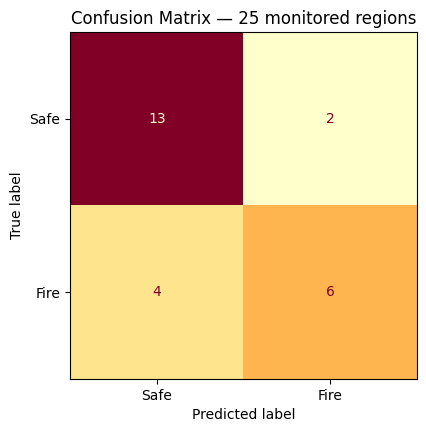

In [3]:
tn, fp, fn, tp = confusion_matrix(demo["actual"], demo["predicted"], labels=[0, 1]).ravel()
print(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(demo["actual"], demo["predicted"], labels=[0, 1]),
    display_labels=["Safe", "Fire"]
)
disp.plot(cmap="YlOrRd", colorbar=False)
plt.title("Confusion Matrix — 25 monitored regions")
plt.show()


**Checkpoint:** this should give TP=6, TN=13, FP=2, FN=4 — matching the slide's worked example.


## 2. Recall — "of every real fire, how many did we catch?"

$$Recall = \frac{TP}{TP + FN}$$

The denominator is every region that was **actually** on fire, whether caught or not. Recall never looks at safe regions — TN and FP don't appear in this formula at all.


In [4]:
recall_manual = tp / (tp + fn)
print(f"Recall = {tp} / ({tp}+{fn}) = {recall_manual:.3f}")

recall_sklearn = recall_score(demo["actual"], demo["predicted"])
print(f"Recall (sklearn): {recall_sklearn:.3f}")
assert np.isclose(recall_manual, recall_sklearn)
print("Manual calculation matches sklearn ✔")


Recall = 6 / (6+4) = 0.600
Recall (sklearn): 0.600
Manual calculation matches sklearn ✔


## 3. Why Recall can matter more than Precision

Let's build a stricter model that only flags "Fire Risk" when very confident. It catches just 4 of the 10 real fires, but never raises a false alarm.


In [5]:
strict_actual =    np.array([1]*10 + [0]*15)
strict_predicted = np.array([1]*4 + [0]*6 + [0]*15)   # of 10 real fires: 4 caught, 6 missed; 15 safe regions all correctly cleared

strict_precision = precision_score(strict_actual, strict_predicted)
strict_recall = recall_score(strict_actual, strict_predicted)

print(f"Precision: {strict_precision:.3f}")
print(f"Recall:    {strict_recall:.3f}")


Precision: 1.000
Recall:    0.400


**The gap:** 100% precision looks perfect — every alarm this model raises is real. But Recall of 0.4 reveals that 6 of the 10 actual fires went completely undetected. Precision alone would never surface that; only Recall shows how much real danger slipped through.


## 4. F1-Score — the harmonic mean of Precision and Recall

$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

F1 is not a simple average — it's a harmonic mean, which punishes an imbalance between the two much more harshly than an average would. Let's see this directly with an extreme example: Precision = 0.15, Recall = 0.95.


In [6]:
def f1_from_pr(precision, recall):
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

extreme_precision, extreme_recall = 0.15, 0.95
simple_average = (extreme_precision + extreme_recall) / 2
harmonic_mean = f1_from_pr(extreme_precision, extreme_recall)

print(f"Simple average: {simple_average:.3f}")
print(f"F1 (harmonic mean): {harmonic_mean:.3f}")


Simple average: 0.550
F1 (harmonic mean): 0.259


A simple average calls this model "0.55 good." The harmonic mean drags it down to 0.259 — F1 refuses to let a very high Recall hide a very low Precision.


## 5. Calculating F1 on our 25-region matrix


In [7]:
precision_manual = tp / (tp + fp)
f1_manual = f1_from_pr(precision_manual, recall_manual)

print(f"Precision = {precision_manual:.3f}")
print(f"Recall    = {recall_manual:.3f}")
print(f"F1        = 2 * ({precision_manual:.3f} * {recall_manual:.3f}) / ({precision_manual:.3f} + {recall_manual:.3f}) = {f1_manual:.3f}")

f1_sklearn = f1_score(demo["actual"], demo["predicted"])
print(f"F1 (sklearn): {f1_sklearn:.3f}")
assert np.isclose(f1_manual, f1_sklearn)
print("Manual calculation matches sklearn ✔")


Precision = 0.750
Recall    = 0.600
F1        = 2 * (0.750 * 0.600) / (0.750 + 0.600) = 0.667
F1 (sklearn): 0.667
Manual calculation matches sklearn ✔


## 6. Balancing Precision and Recall — three models compared

Let's build three models on the same 25 regions: one that chases Recall, one that chases Precision, and one that aims for both.


In [8]:
def build_and_score(tp, fn, fp, tn, label):
    actual = np.array([1]*(tp+fn) + [0]*(fp+tn))
    predicted = np.array([1]*tp + [0]*fn + [1]*fp + [0]*tn)
    return {
        "model": label,
        "recall": recall_score(actual, predicted),
        "precision": precision_score(actual, predicted),
        "f1": f1_score(actual, predicted),
    }

model_a = build_and_score(9, 1, 8, 7, "A (recall-focused)")
model_b = build_and_score(4, 6, 0, 15, "B (precision-focused)")
model_c = build_and_score(7, 3, 2, 13, "C (balanced)")

comparison = pd.DataFrame([model_a, model_b, model_c]).set_index("model")
comparison.round(3)


,recall,precision,f1
model,,,
A (recall-focused),0.9,0.529,0.667
B (precision-focused),0.4,1.000,0.571
C (balanced),0.7,0.778,0.737


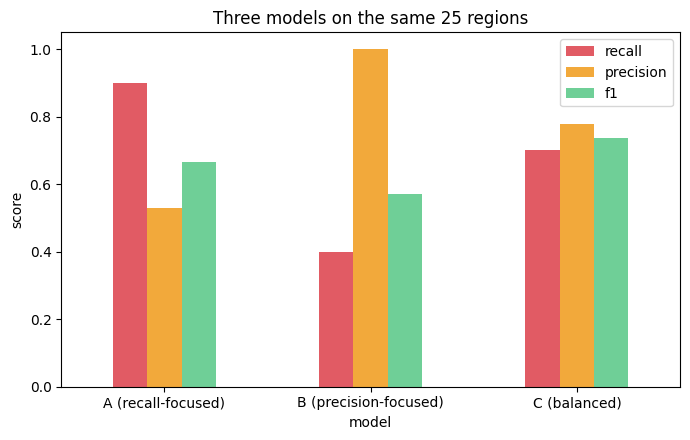

In [9]:
comparison[["recall", "precision", "f1"]].plot(kind="bar", color=["#E15B64", "#F2A93B", "#6FCF97"])
plt.title("Three models on the same 25 regions")
plt.ylabel("score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Notice Model C doesn't have the single highest Recall (that's A) or the single highest Precision (that's B) — but it has the highest **F1**. That's what "balancing precision and recall" means in practice.


## 7. The precision-recall trade-off on a real dataset

To see the threshold trade-off on genuine data rather than a hand-built example, we'll use scikit-learn's built-in **breast cancer diagnostic dataset** (569 real patient scans, 30 measured features, malignant/benign) — the same real, pre-built benchmark used in the previous session. We'll treat "malignant" as our positive class, the case most analogous to a real fire: the one you most need to catch.


In [10]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

cancer = load_breast_cancer()
X = cancer.data
y = (cancer.target == 0).astype(int)   # flip so 1 = malignant (positive class)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=5000)
clf.fit(X_train_scaled, y_train)

predicted_scores = clf.predict_proba(X_test_scaled)[:, 1]
print(f"Test set size: {len(y_test)}   Malignant in test set: {y_test.sum()}")


Test set size: 171   Malignant in test set: 64


In [11]:
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
rows = []
for t in thresholds:
    labels_t = (predicted_scores >= t).astype(int)
    rows.append({
        "threshold": t,
        "recall": recall_score(y_test, labels_t, zero_division=0),
        "precision": precision_score(y_test, labels_t, zero_division=0),
        "f1": f1_score(y_test, labels_t, zero_division=0),
        "n_flagged": labels_t.sum(),
    })

threshold_df = pd.DataFrame(rows)
threshold_df


,threshold,recall,precision,f1,n_flagged
0,0.1,0.984375,0.900000,0.940299,70
1,0.3,0.968750,0.984127,0.976378,63
2,0.5,0.937500,0.983607,0.960000,61
3,0.7,0.921875,1.000000,0.959350,59
4,0.9,0.796875,1.000000,0.886957,51


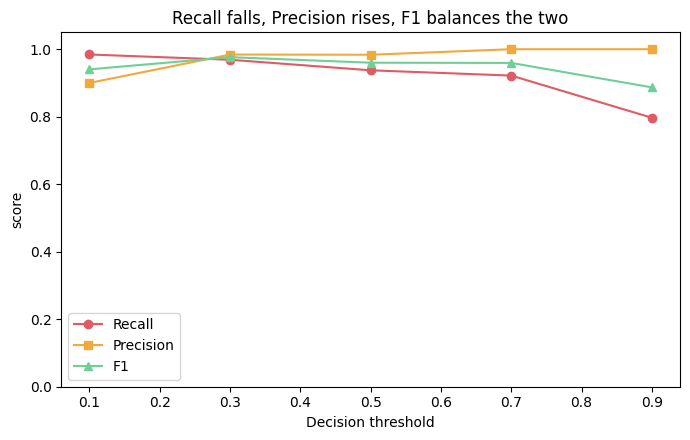

In [12]:
fig, ax = plt.subplots()
ax.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", color="#E15B64", label="Recall")
ax.plot(threshold_df["threshold"], threshold_df["precision"], marker="s", color="#F2A93B", label="Precision")
ax.plot(threshold_df["threshold"], threshold_df["f1"], marker="^", color="#6FCF97", label="F1")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("score")
ax.set_ylim(0, 1.05)
ax.set_title("Recall falls, Precision rises, F1 balances the two")
ax.legend()
plt.tight_layout()
plt.show()


Notice Recall falls and Precision rises as the threshold increases — the classic trade-off. F1 traces a path between them, staying highest around the threshold where neither metric is badly neglected.


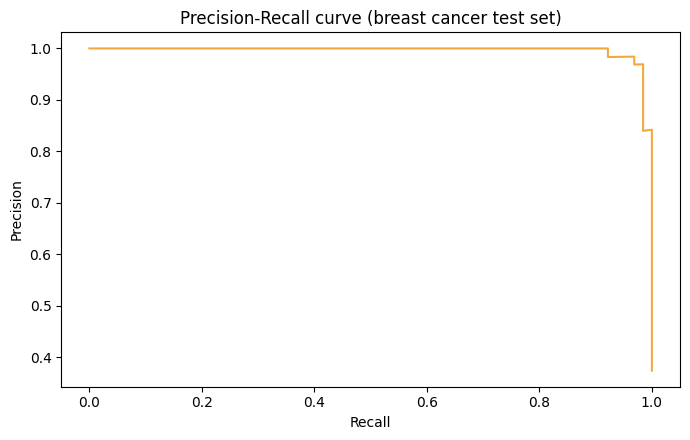

In [13]:
# scikit-learn also provides precision_recall_curve for a finer-grained view across every possible threshold
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, predicted_scores)

fig, ax = plt.subplots()
ax.plot(recalls, precisions, color="#F2A93B")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curve (breast cancer test set)")
plt.tight_layout()
plt.show()


## 8. Exercises

Work through these before checking the solutions.


### Exercise 1 — Compute Recall and F1 by hand
Given TP=8, TN=40, FP=12, FN=5, compute Recall and F1 by hand, then verify using the formulas above. (Precision for this data is 8/(8+12) = 0.4, computed the same way as last session.)


In [14]:
# TODO: compute manually
tp_ex, tn_ex, fp_ex, fn_ex = 8, 40, 12, 5


<details><summary>Show solution</summary>

```python
recall_ex = tp_ex / (tp_ex + fn_ex)
precision_ex = tp_ex / (tp_ex + fp_ex)
f1_ex = f1_from_pr(precision_ex, recall_ex)
print(recall_ex, precision_ex, f1_ex)   # Recall ≈ 0.615, Precision = 0.4, F1 ≈ 0.485
```
</details>


### Exercise 2 — Diagnose which metric a model is neglecting
A wildfire model reports Precision = 0.95 and Recall = 0.2. Without computing F1, what does this combination suggest is happening, and would you deploy this model as-is?


<details><summary>Show solution</summary>

Very high Precision with very low Recall suggests the model is extremely conservative — it almost never raises a false alarm, but it's also missing the vast majority of real fires (80% of them, based on Recall=0.2). For a wildfire detector, this is dangerous despite the reassuring Precision number: F1 here would be roughly 2*(0.95*0.2)/(0.95+0.2) ≈ 0.331, a low score that reflects just how much real risk is going uncaught. This model would likely need retuning (a lower threshold) before deployment.
</details>


### Exercise 3 — Find the threshold that maximizes F1
Using `clf`, `predicted_scores`, and `y_test` from Section 7, sweep thresholds from 0.05 to 0.95 and find the one that gives the highest F1-Score. Report the Recall and Precision at that threshold too.


In [15]:
# TODO: sweep thresholds, compute F1 at each, and find the threshold with the maximum F1



<details><summary>Show solution</summary>

```python
best_threshold, best_f1 = None, -1
for t in np.arange(0.05, 0.96, 0.01):
    labels_t = (predicted_scores >= t).astype(int)
    f1_t = f1_score(y_test, labels_t, zero_division=0)
    if f1_t > best_f1:
        best_f1, best_threshold = f1_t, t

best_labels = (predicted_scores >= best_threshold).astype(int)
print(f"Best threshold: {best_threshold:.2f}")
print(f"F1:        {best_f1:.3f}")
print(f"Recall:    {recall_score(y_test, best_labels):.3f}")
print(f"Precision: {precision_score(y_test, best_labels):.3f}")
```
The exact best threshold depends on the train/test split above, but it typically lands well below 0.9 — confirming that chasing the single highest Precision or Recall is usually not what maximizes F1.
</details>


## 9. Recap

- **Recall** = TP/(TP+FN) — of everything that was actually positive, how much did the model catch. Also called sensitivity.
- **F1-Score** = 2×(Precision×Recall)/(Precision+Recall) — the harmonic mean of the two, which punishes imbalance between them far more than a simple average would.
- A model can have perfect Precision and still be dangerous if its Recall is low — and vice versa.
- **Balancing precision and sensitivity** means choosing a threshold (or a model) that doesn't sacrifice one metric entirely to maximize the other — F1 is the single number that captures whether that balance has been struck.
